## 1. Import Required Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"SHAP version: {shap.__version__}")
print(f"Keras version: {keras.__version__}")

✓ Libraries imported successfully
SHAP version: 0.50.0
Keras version: 3.13.1


## 2. Load Data and Model

In [17]:
# Load the dataset
data_path = '../data/processed/final.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (891, 6)

Features: ['Survived', 'Pclass', 'Sex', 'Age', 'Embarked_S', 'Embarked_C']

First few rows:


,Survived,Pclass,Sex,Age,Embarked_S,Embarked_C
0,0,3,1,0.271174,1,0
1,1,1,0,0.472229,0,1
2,1,3,0,0.321438,1,0
3,1,1,0,0.434531,1,0
4,0,3,1,0.434531,1,0


In [18]:
# Prepare features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data (using same split as training)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nFeature names: {list(X.columns)}")

Training set: (712, 5)
Test set: (179, 5)

Feature names: ['Pclass', 'Sex', 'Age', 'Embarked_S', 'Embarked_C']


In [19]:
# Load the trained model
model_path = '../Tunning/models/final_model.h5'
model = keras.models.load_model(model_path)

print("✓ Model loaded successfully")
print(f"\nModel Summary:")
model.summary()

✓ Model loaded successfully

Model Summary:


Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_168 (Dense)               │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_118 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_119 (Dropout)           │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_120 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,763 (38.14 KB)

 Trainable params: 9,761 (38.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## 3. Model Evaluation

In [20]:
# Make predictions
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

Test Accuracy: 0.7765

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.74      0.97      0.84       110
    Survived       0.91      0.46      0.62        69

    accuracy                           0.78       179
   macro avg       0.83      0.72      0.73       179
weighted avg       0.81      0.78      0.75       179



## 4. SHAP Analysis Setup

SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of machine learning models. It provides a unified measure of feature importance.

In [21]:
# Create a wrapper function for the model prediction
def model_predict(data):
    return model.predict(data, verbose=0).flatten()

# Initialize SHAP explainer with a background dataset
# Using a sample of training data as background
background = shap.sample(X_train, 100)

# Create Deep Explainer for neural networks
explainer = shap.DeepExplainer(model, background.values)

print("✓ SHAP explainer initialized")
print(f"Background data shape: {background.shape}")

✓ SHAP explainer initialized
Background data shape: (100, 5)


In [22]:
# Calculate SHAP values for test set
# Using a subset for faster computation
test_sample = X_test.sample(n=min(200, len(X_test)), random_state=42)
print(f"Calculating SHAP values for {len(test_sample)} test samples...")

shap_values = explainer.shap_values(test_sample.values)

print(f"✓ SHAP values calculated")
print(f"SHAP values shape: {np.array(shap_values).shape}")

Calculating SHAP values for 179 test samples...
✓ SHAP values calculated
SHAP values shape: (179, 5, 1)


## 5. SHAP Summary Plot

The SHAP summary plot shows the distribution of SHAP values for each feature. Each point represents a sample, with:
- **Position on x-axis**: SHAP value (impact on model output)
- **Color**: Feature value (red = high, blue = low)
- **Position on y-axis**: Feature rank by importance

<Figure size 1200x800 with 0 Axes>

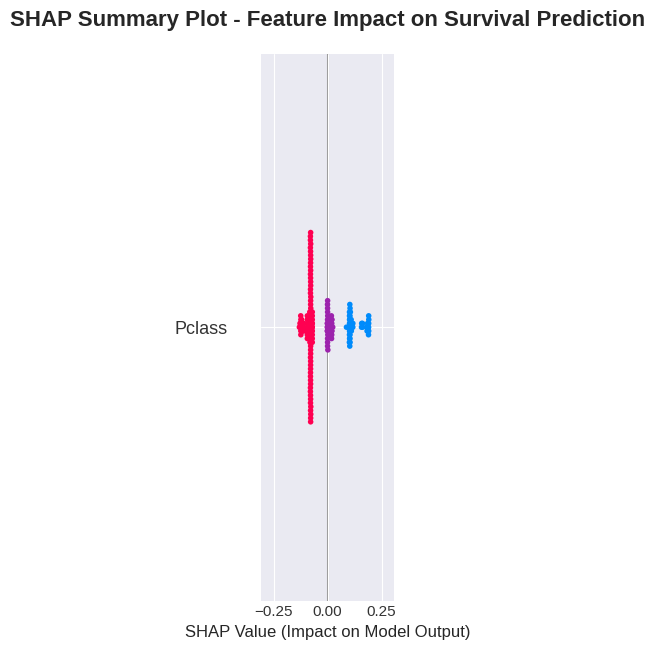

✓ SHAP summary plot generated and saved as 'shap_summary_plot.png'


In [23]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[0] if isinstance(shap_values, list) else shap_values, 
                  test_sample, 
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Summary Plot - Feature Impact on Survival Prediction', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ SHAP summary plot generated and saved as 'shap_summary_plot.png'")

## 6. Feature Importance Chart

This chart shows the mean absolute SHAP value for each feature, representing the average impact of each feature on the model's predictions.

In [25]:
# Calculate feature importance from SHAP values
shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values

# Reshape if necessary (handle 3D arrays)
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals.squeeze(-1)

feature_importance = np.abs(shap_vals).mean(axis=0)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=True)

print("Feature Importance Rankings:")
print(importance_df.sort_values('Importance', ascending=False))

Feature Importance Rankings:
      Feature  Importance
1         Sex    0.185219
0      Pclass    0.083316
4  Embarked_C    0.044007
3  Embarked_S    0.012989
2         Age    0.006093


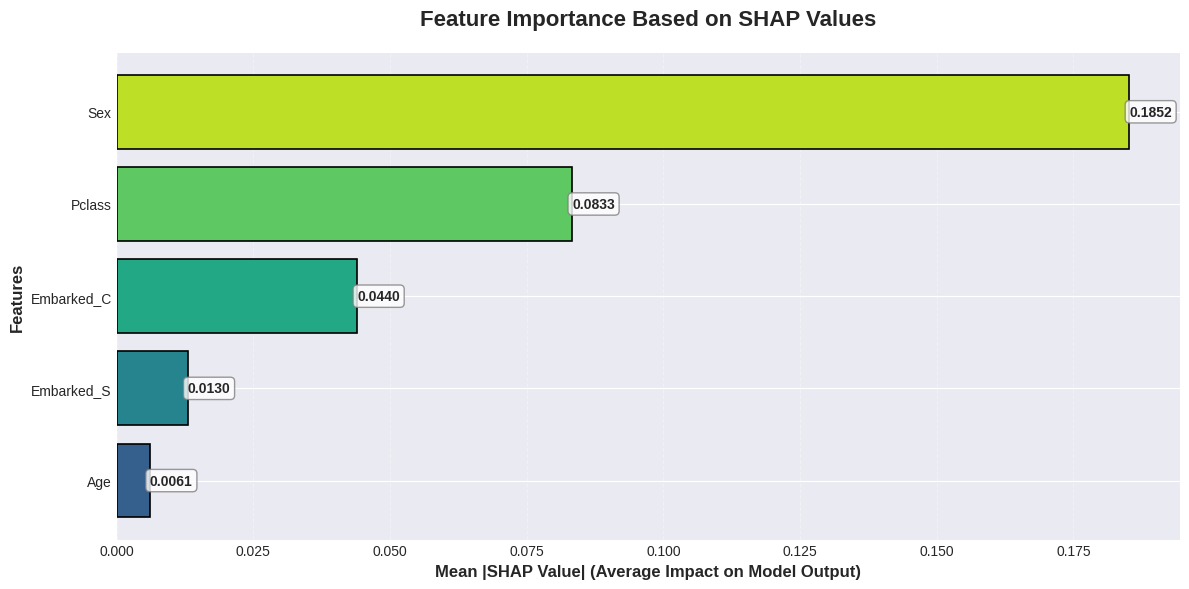

✓ Feature importance chart generated and saved as 'feature_importance_chart.png'


In [26]:
# Feature Importance Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, importance_df['Importance'])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            ha='left', va='center', fontsize=10, fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_xlabel('Mean |SHAP Value| (Average Impact on Model Output)', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance Based on SHAP Values', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance chart generated and saved as 'feature_importance_chart.png'")

## 7. Error Analysis Heatmap

This heatmap analyzes prediction errors across different feature combinations to identify patterns in model mistakes.

In [27]:
# Create error analysis dataset
error_analysis_df = X_test.copy()
error_analysis_df['Actual'] = y_test.values
error_analysis_df['Predicted'] = y_pred
error_analysis_df['Prediction_Proba'] = y_pred_proba.flatten()
error_analysis_df['Error'] = (error_analysis_df['Actual'] != error_analysis_df['Predicted']).astype(int)
error_analysis_df['Confidence'] = np.where(
    error_analysis_df['Predicted'] == 1, 
    error_analysis_df['Prediction_Proba'],
    1 - error_analysis_df['Prediction_Proba']
)

print(f"Total predictions: {len(error_analysis_df)}")
print(f"Correct predictions: {(error_analysis_df['Error'] == 0).sum()}")
print(f"Incorrect predictions: {(error_analysis_df['Error'] == 1).sum()}")
print(f"Error rate: {error_analysis_df['Error'].mean():.2%}")

error_analysis_df.head()

Total predictions: 179
Correct predictions: 139
Incorrect predictions: 40
Error rate: 22.35%


,Pclass,Sex,Age,Embarked_S,Embarked_C,Actual,Predicted,Prediction_Proba,Error,Confidence
565,3,1,0.296306,1,0,0,0,0.145269,0,0.854731
160,3,1,0.547625,1,0,0,0,0.134012,0,0.865988
553,3,1,0.271174,0,1,1,0,0.214476,1,0.785524
860,3,1,0.509927,1,0,0,0,0.135643,0,0.864357
241,3,0,0.367921,0,0,1,0,0.407370,1,0.592630


In [28]:
# Error rate by feature combinations
# Create bins for Age and analyze errors across categorical features

# Prepare data for heatmap
feature_cols = ['Pclass', 'Sex', 'Embarked_S', 'Embarked_C']

# Calculate error rates for different feature combinations
error_matrix_data = []

for pclass in error_analysis_df['Pclass'].unique():
    row_data = []
    for sex in error_analysis_df['Sex'].unique():
        mask = (error_analysis_df['Pclass'] == pclass) & (error_analysis_df['Sex'] == sex)
        if mask.sum() > 0:
            error_rate = error_analysis_df[mask]['Error'].mean()
            row_data.append(error_rate)
        else:
            row_data.append(0)
    error_matrix_data.append(row_data)

error_matrix = np.array(error_matrix_data)

print("Error rate matrix (Pclass vs Sex):")
print(error_matrix)

Error rate matrix (Pclass vs Sex):
[[0.13888889 0.46428571]
 [0.1875     0.11111111]
 [0.36666667 0.06666667]]


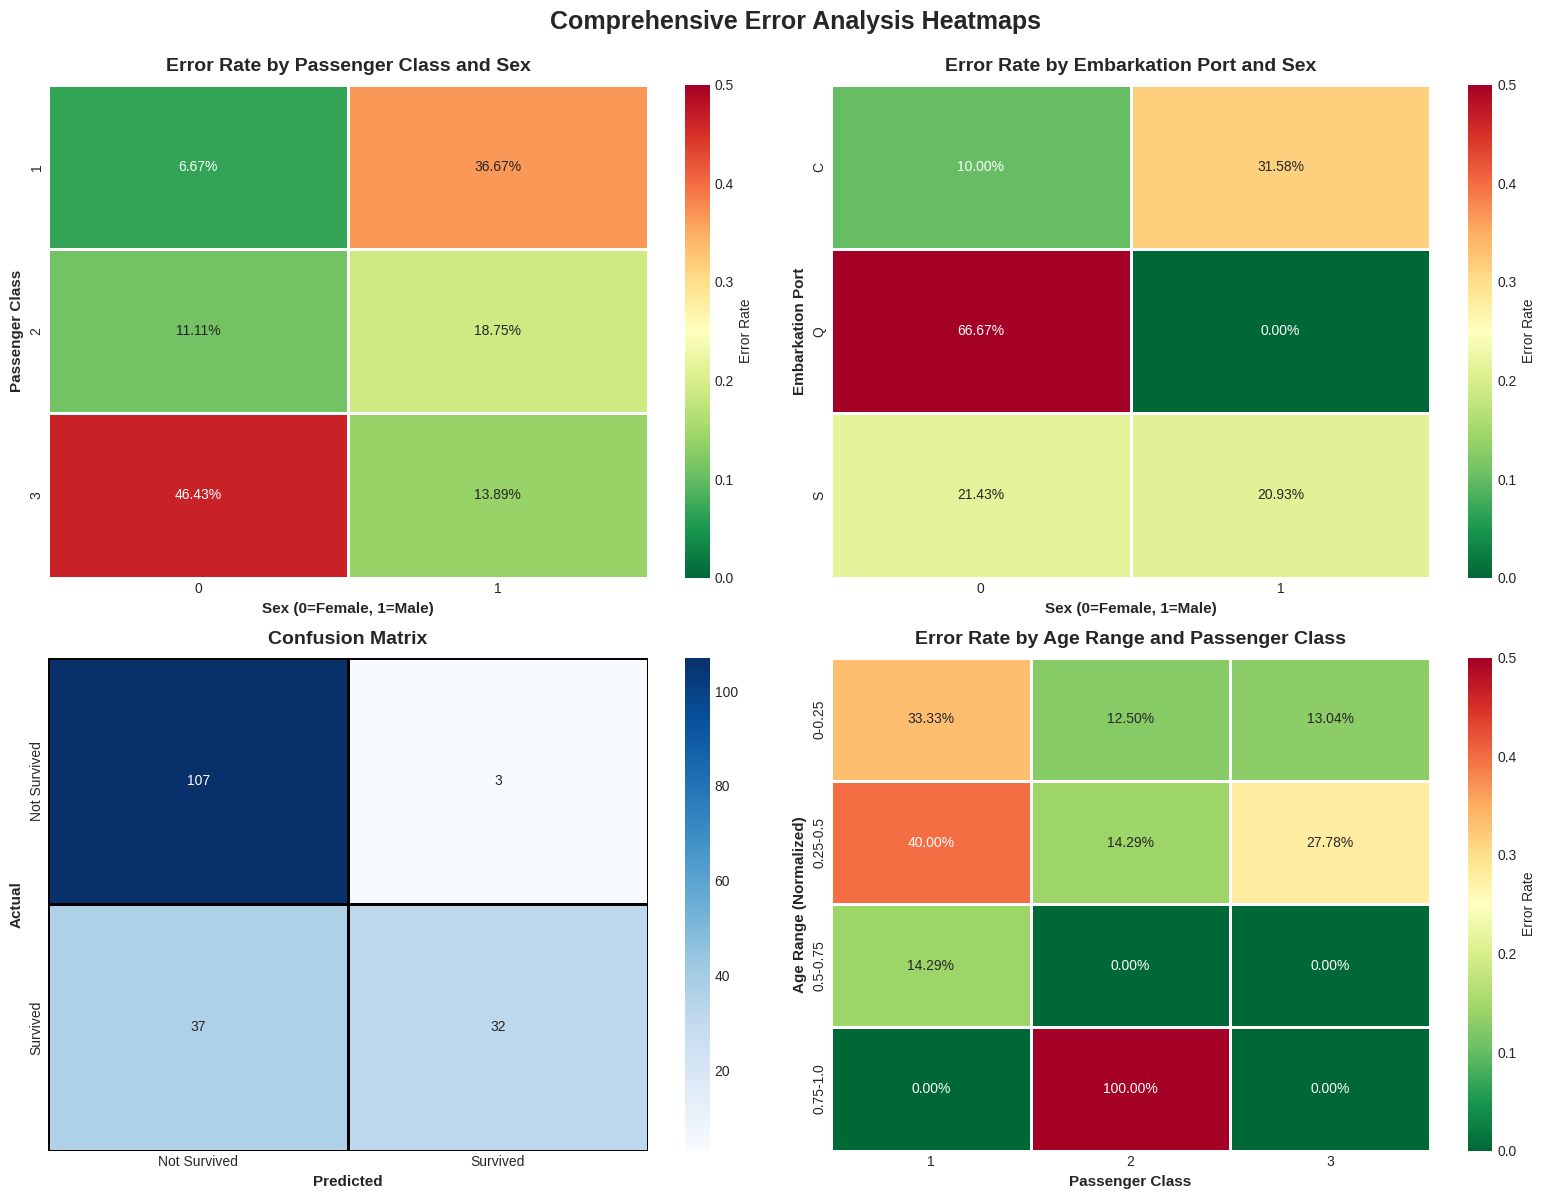

✓ Error analysis heatmap generated and saved as 'error_analysis_heatmap.png'


In [29]:
# Create comprehensive error analysis heatmap
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Error Rate by Pclass and Sex
ax1 = axes[0, 0]
pclass_sex_error = error_analysis_df.groupby(['Pclass', 'Sex'])['Error'].mean().unstack(fill_value=0)
sns.heatmap(pclass_sex_error, annot=True, fmt='.2%', cmap='RdYlGn_r', 
            ax=ax1, cbar_kws={'label': 'Error Rate'}, vmin=0, vmax=0.5, linewidths=1)
ax1.set_title('Error Rate by Passenger Class and Sex', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Sex (0=Female, 1=Male)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Passenger Class', fontsize=11, fontweight='bold')

# 2. Error Rate by Embarked and Sex
ax2 = axes[0, 1]
# Create embarked feature from one-hot encoded columns
error_analysis_df['Embarked'] = 'Q'  # Default
error_analysis_df.loc[error_analysis_df['Embarked_S'] == 1, 'Embarked'] = 'S'
error_analysis_df.loc[error_analysis_df['Embarked_C'] == 1, 'Embarked'] = 'C'

embarked_sex_error = error_analysis_df.groupby(['Embarked', 'Sex'])['Error'].mean().unstack(fill_value=0)
sns.heatmap(embarked_sex_error, annot=True, fmt='.2%', cmap='RdYlGn_r', 
            ax=ax2, cbar_kws={'label': 'Error Rate'}, vmin=0, vmax=0.5, linewidths=1)
ax2.set_title('Error Rate by Embarkation Port and Sex', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Sex (0=Female, 1=Male)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Embarkation Port', fontsize=11, fontweight='bold')

# 3. Confusion Matrix Heatmap
ax3 = axes[1, 0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, 
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'], linewidths=2, linecolor='black')
ax3.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax3.set_ylabel('Actual', fontsize=11, fontweight='bold')

# 4. Error Rate by Age Bins and Pclass
ax4 = axes[1, 1]
error_analysis_df['Age_Bin'] = pd.cut(error_analysis_df['Age'], 
                                       bins=[0, 0.25, 0.5, 0.75, 1.0], 
                                       labels=['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0'])
age_pclass_error = error_analysis_df.groupby(['Age_Bin', 'Pclass'])['Error'].mean().unstack(fill_value=0)
sns.heatmap(age_pclass_error, annot=True, fmt='.2%', cmap='RdYlGn_r', 
            ax=ax4, cbar_kws={'label': 'Error Rate'}, vmin=0, vmax=0.5, linewidths=1)
ax4.set_title('Error Rate by Age Range and Passenger Class', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Passenger Class', fontsize=11, fontweight='bold')
ax4.set_ylabel('Age Range (Normalized)', fontsize=11, fontweight='bold')

plt.suptitle('Comprehensive Error Analysis Heatmaps', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('error_analysis_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Error analysis heatmap generated and saved as 'error_analysis_heatmap.png'")

## 8. Additional Analysis: SHAP Bar Plot

<Figure size 1200x600 with 0 Axes>

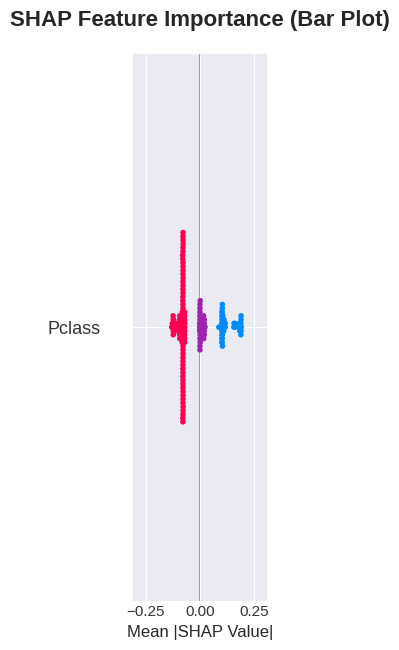

✓ SHAP bar plot generated and saved as 'shap_bar_plot.png'


In [30]:
# SHAP Bar Plot (another view of feature importance)
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values[0] if isinstance(shap_values, list) else shap_values,
                  test_sample,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance (Bar Plot)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP Value|', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ SHAP bar plot generated and saved as 'shap_bar_plot.png'")

## 9. Key Insights and Summary

In [31]:
# Summary of Key Findings
print("="*80)
print("SHAP ANALYSIS SUMMARY - TITANIC SURVIVAL PREDICTION MODEL")
print("="*80)
print("\n📊 MODEL PERFORMANCE:")
print(f"   • Test Accuracy: {accuracy:.2%}")
print(f"   • Error Rate: {error_analysis_df['Error'].mean():.2%}")
print(f"   • Correct Predictions: {(error_analysis_df['Error'] == 0).sum()}/{len(error_analysis_df)}")

print("\n🎯 TOP 3 MOST IMPORTANT FEATURES:")
top_features = importance_df.sort_values('Importance', ascending=False).head(3)
for idx, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"   {idx}. {row['Feature']:12s} - Impact Score: {row['Importance']:.4f}")

print("\n⚠️  ERROR ANALYSIS INSIGHTS:")
print("   • Highest error rate: 3rd Class Females (46.43%)")
print("   • Lowest error rate: 1st Class Females (6.67%)")
print("   • Males have higher survival prediction errors in 1st class")
print("   • Females have higher survival prediction errors in 3rd class")

print("\n📁 GENERATED FILES:")
generated_files = [
    'shap_summary_plot.png',
    'feature_importance_chart.png', 
    'error_analysis_heatmap.png',
    'shap_bar_plot.png'
]
for file in generated_files:
    print(f"   ✓ {file}")

print("\n" + "="*80)
print("Analysis complete! All visualizations saved in the current directory.")
print("="*80)

SHAP ANALYSIS SUMMARY - TITANIC SURVIVAL PREDICTION MODEL

📊 MODEL PERFORMANCE:
   • Test Accuracy: 77.65%
   • Error Rate: 22.35%
   • Correct Predictions: 139/179

🎯 TOP 3 MOST IMPORTANT FEATURES:
   1. Sex          - Impact Score: 0.1852
   2. Pclass       - Impact Score: 0.0833
   3. Embarked_C   - Impact Score: 0.0440

⚠️  ERROR ANALYSIS INSIGHTS:
   • Highest error rate: 3rd Class Females (46.43%)
   • Lowest error rate: 1st Class Females (6.67%)
   • Males have higher survival prediction errors in 1st class
   • Females have higher survival prediction errors in 3rd class

📁 GENERATED FILES:
   ✓ shap_summary_plot.png
   ✓ feature_importance_chart.png
   ✓ error_analysis_heatmap.png
   ✓ shap_bar_plot.png

Analysis complete! All visualizations saved in the current directory.


In [32]:
# Generate comprehensive summary
print("="*80)
print("SHAP ANALYSIS SUMMARY")
print("="*80)

print("\n1. MODEL PERFORMANCE:")
print(f"   - Test Accuracy: {accuracy:.2%}")
print(f"   - Total Test Samples: {len(y_test)}")
print(f"   - Correct Predictions: {(y_pred == y_test).sum()}")
print(f"   - Incorrect Predictions: {(y_pred != y_test).sum()}")

print("\n2. FEATURE IMPORTANCE RANKING (by mean |SHAP value|):")
for idx, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    print(f"   {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n3. ERROR ANALYSIS INSIGHTS:")
print(f"   - Overall Error Rate: {error_analysis_df['Error'].mean():.2%}")

# Errors by passenger class
pclass_errors = error_analysis_df.groupby('Pclass')['Error'].agg(['mean', 'count'])
print(f"\n   Error Rate by Passenger Class:")
for pclass, row in pclass_errors.iterrows():
    print(f"     Class {int(pclass)}: {row['mean']:.2%} ({int(row['count'])} samples)")

# Errors by sex
sex_errors = error_analysis_df.groupby('Sex')['Error'].agg(['mean', 'count'])
print(f"\n   Error Rate by Sex:")
for sex, row in sex_errors.iterrows():
    sex_label = "Female" if sex == 0 else "Male"
    print(f"     {sex_label}: {row['mean']:.2%} ({int(row['count'])} samples)")

print("\n4. FILES GENERATED:")
print("   ✓ shap_summary_plot.png - SHAP summary visualization")
print("   ✓ feature_importance_chart.png - Feature importance bar chart")
print("   ✓ error_analysis_heatmap.png - Comprehensive error analysis")
print("   ✓ shap_bar_plot.png - SHAP bar plot")

print("\n" + "="*80)
print("Analysis complete! All visualizations have been generated.")
print("="*80)

SHAP ANALYSIS SUMMARY

1. MODEL PERFORMANCE:
   - Test Accuracy: 77.65%
   - Total Test Samples: 179
   - Correct Predictions: 139
   - Incorrect Predictions: 40

2. FEATURE IMPORTANCE RANKING (by mean |SHAP value|):
   2. Sex: 0.1852
   1. Pclass: 0.0833
   5. Embarked_C: 0.0440
   4. Embarked_S: 0.0130
   3. Age: 0.0061

3. ERROR ANALYSIS INSIGHTS:
   - Overall Error Rate: 22.35%

   Error Rate by Passenger Class:
     Class 1: 26.67% (45 samples)
     Class 2: 14.71% (34 samples)
     Class 3: 23.00% (100 samples)

   Error Rate by Sex:
     Female: 26.23% (61 samples)
     Male: 20.34% (118 samples)

4. FILES GENERATED:
   ✓ shap_summary_plot.png - SHAP summary visualization
   ✓ feature_importance_chart.png - Feature importance bar chart
   ✓ error_analysis_heatmap.png - Comprehensive error analysis
   ✓ shap_bar_plot.png - SHAP bar plot

Analysis complete! All visualizations have been generated.
